In [1]:
import gc
import os
import shutil
import zipfile
import warnings
from glob import glob
from dataclasses import dataclass

import cv2
import requests
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import  torch.nn as nn
from torch.cuda import amp
from torch.optim import Adam
import  torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy

from torchinfo import summary

# for data augumentations and preprocessing
import albumentations as A
from albumentations.pytorch import ToTensorV2

# For plotting training and validation metrics.
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot, ExtremaPrinter

plt.rcParams['image.cmap'] = 'gray'

# To filter UserWarning.
warnings.filterwarnings("ignore", category=UserWarning)

## download dataset

In [2]:
def download_unzip(url, save_path):
    file = requests.get(url)
    with open(save_path, "wb") as f:
        f.write(file.content)
    
    try:
        with zipfile.ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])
            print("Done")
    except:
        print("Invalid file")


In [4]:
URL = r"https://www.dropbox.com/s/jd4o138i8nx6cth/dataset_kitti_road_segmentation.zip?dl=1"

dataset_name = "dataset_kitti_road_segmentation"
dataset_zip_path = os.path.join(os.getcwd(), f"{dataset_name}.zip")
dataset_path = os.path.join(os.getcwd(), dataset_name)

# Download if dataset does not exists.
if not os.path.exists(dataset_path):
    download_unzip(URL, dataset_zip_path)
    # shutil.rmtree(dataset_zip_path) # Remove the ZIP file to free storage space.

Done


## Device selection & benchmarking behaviour


In [ ]:
def get_default_device():
    gpu_available = torch.cuda.is_available()
    return torch.device('cuda' if gpu_available else 'cpu'), gpu_available

## Training & dataset configurations

In [7]:
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 2
    IMG_WIDTH:   int = 224
    IMG_HEIGHT:  int = 224

    DATA_TRAIN_IMAGES: str = os.path.join(dataset_path, "train", "images", r"*.png")
    DATA_TRAIN_LABELS: str = os.path.join(dataset_path, "train", "masks",  r"*.png")
    DATA_VALID_IMAGES: str = os.path.join(dataset_path, "valid", "images", r"*.png")
    DATA_VALID_LABELS: str = os.path.join(dataset_path, "valid", "masks",  r"*.png")


@dataclass(frozen=True)
class TrainingConfig:
    BATCH_SIZE:      int = 8
    EPOCHS:          int = 50
    LEARNING_RATE: float = 0.0001
    CHECKPOINT_DIR:  str = os.path.join('model_checkpoint', 'FCN_Road')
    NUM_WORKERS:     int = os.cpu_count()


@dataclass(frozen=True)
class InferenceConfig:
    BATCH_SIZE:  int = 4
    NUM_BATCHES: int = 2

# modelling FCN-32s with VGG-16 backbone

In [8]:
class VGGCommonBlock(nn.Module):
    def __init__(self, out_channels = 64, num_conv_layers = 3):
        super().__init__()

        layers = []
        for i in range(num_conv_layers):
            layers.append(nn.LazyConv2d(out_channels = out_channels,
                                        kernel_size = (3,3),
                                        stride = 1,
                                        padding = 'same',
                                        bias = False))
            layers.append(nn.LazyBatchNorm2d())
            layers.append(nn.ReLU())

        layers.append(nn.MaxPool2d(kernel_size = 2))
        self.block = nn.Sequential(*layers)

    def forward(self,x):
        return self.block(x)

In [11]:
class FCN32S_VGG16(nn.Module):
    def __init__(self, num_classes = 21):
        super().__init__()

        # Conv block 1
        self.block_1 = VGGCommonBlock(out_channels = 64, num_conv_layers = 2)

        # Conv block 2
        self.block_2 = VGGCommonBlock(out_channels = 128, num_conv_layers = 2)

        # Conv block 3
        self.block_3 = VGGCommonBlock(out_channels = 256, num_conv_layers = 3)

        # Conv block 4
        self.block_4 = VGGCommonBlock(out_channels = 512, num_conv_layers = 3)

        # Conv block 5
        self.block_5 = VGGCommonBlock(out_channels = 512, num_conv_layers = 3)

        # FCN Head
        self.conv_1x1 = nn.LazyConv2d(out_channels = num_classes, kernel_size = (1,1),
                                      stride = 1, padding = 'same')

        # upsampling using transposed convolution
        self.conv_transpose = nn.LazyConvTranspose2d(out_channels = num_classes, kernel_size = (64,64),
                                                     stride = (32,32), padding = (16,16))

    def forward(self,x):
        # Backbone
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.block_4(x)
        x = self.block_5(x)

        # Head
        x = self.conv_1x1(x)
        x = self.conv_transpose(x)

        return x

     

In [12]:
model = FCN32S_VGG16(num_classes = DatasetConfig.NUM_CLASSES)
model.eval()

summary(model, input_size = (1, 3, DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH))

Layer (type:depth-idx)                   Output Shape              Param #
FCN32S_VGG16                             [1, 2, 224, 224]          --
├─VGGCommonBlock: 1-1                    [1, 64, 112, 112]         --
│    └─Sequential: 2-1                   [1, 64, 112, 112]         --
│    │    └─Conv2d: 3-1                  [1, 64, 224, 224]         1,728
│    │    └─BatchNorm2d: 3-2             [1, 64, 224, 224]         128
│    │    └─ReLU: 3-3                    [1, 64, 224, 224]         --
│    │    └─Conv2d: 3-4                  [1, 64, 224, 224]         36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 224, 224]         128
│    │    └─ReLU: 3-6                    [1, 64, 224, 224]         --
│    │    └─MaxPool2d: 3-7               [1, 64, 112, 112]         --
├─VGGCommonBlock: 1-2                    [1, 128, 56, 56]          --
│    └─Sequential: 2-2                   [1, 128, 56, 56]          --
│    │    └─Conv2d: 3-8                  [1, 128, 112, 112]        73,728
│ 

## custom dataset class

In [13]:
class CustomSegDataset(Dataset):
    def __init__(self, *, 
                 image_size, num_classes,
                 image_paths, mask_paths = None,
                 is_train = False):
        self.image_size = image_size
        self.num_classes = num_classes
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.is_train = is_train
        self.transforms = self.setup_transforms()

    def __len__(self):
        return len(self.image_paths)
    
    def setup_transforms(self):
        transforms = []

        # Data augmentation only for training dataset
        if self.is_train:
            transforms.extend([
                A.HorizontalFlip(p = 0.5),
                A.RandomBrightnessContrast(p = 0.2),
                A.ShiftScaleRotate(shift_limit = 0.1, scale_limit = 0.1, rotate_limit = 15, p = 0.5)
            ])

        # Common transforms for both training and validation datasets
        transforms.extend([
            A.Normalize(mean = [0.485, 0.456, 0.406], 
                        std = [0.229, 0.224, 0.225], 
                        always_apply = True),
            ToTensorV2()
        ])

        return A.Compose(transforms)

    def load_file(self, file_path, interpolation = cv2.INTER_NEAREST):
        file = cv2.imread(file_path, cv2.IMREAD_COLOR)[:,:,::-1]
        file = cv2.resize(file, self.image_size, interpolation = interpolation)
        return file

    def __getitem__(self, index):

        # get image path
        image_path = self.image_paths[index]

        # load image
        image = self.load_file(image_path, interpolation = cv2.INTER_CUBIC)

        if self.mask_paths is not None:

            # get mask path
            mask_path = self.mask_paths[index]

            # load mask
            mask = self.load_file(mask_path, interpolation = cv2.INTER_NEAREST)

            # convert RGB mask to single channel grayscale representation
            mask = rgb_to_grayscale(mask)

            # apply transforms to image_mask pair
            transformed = self.transforms(image = image, mask = mask)
            image, mask = transformed['image'], transformed['mask'].to(torch.long)

            return image, mask

        else: # for test set
            # apply transformations to image
            transformed = self.transforms(image = image)
            image = transformed['image']

            return image



### Helper functions and utilities

In [14]:
id2color = {
    0: (255, 0, 0),   # Background: red
    1: (255, 0, 255), # Road: pink
}

id2color_display = {
    0: (0, 0, 0),     # Background: black
    1: (0, 255, 0),   # Road: green
}


# Reverse id2color mapping.
# Used for converting RGB mask to a single channel (grayscale) representation.
rev_id2color = {value: key for key, value in id2color.items()}

In [15]:
# Function to convert RGB mask to grayscale labels.
def rgb_to_grayscale(rgb_arr, color_map=rev_id2color):

    # Collapse H, W dimensions.
    reshaped_rgb_arr = rgb_arr.reshape((-1, 3))

    # Get an array of all unique pixels along with the "inverse" array
    # (of the same shape as the original array) filled with indices to the unique array.
    # Each value in the "inverse" array points to the unique pixel at that
    # location in the input array.
    unique_pixels, inverse = np.unique(reshaped_rgb_arr, axis=0, return_inverse=True)

    # If the unique pixel is not found in the color_map, class ID of background pixel is used.
    # Here background pixel class ID is 0.
    grayscale_map = np.array([color_map.get(tuple(pixel), 0) for pixel in unique_pixels])[inverse]

    return grayscale_map.reshape(rgb_arr.shape[:2])

In [16]:
# Function to convert a single channel mask representation to an RGB mask.
def num_to_rgb(num_arr, color_map=id2color):
    single_layer = np.squeeze(num_arr)
    output = np.zeros(num_arr.shape[:2] + (3,))

    for k in color_map.keys():
        output[single_layer == k] = color_map[k]

    return np.float32(output) / 255.0 # return a floating point array in range [0.0, 1.0]

In [17]:
# Function to overlay a segmentation map on top of an RGB image.
def image_overlay(image, segmented_image):

    alpha = 1.0 # Transparency for the original image.
    beta  = 0.7 # Transparency for the segmentation map.
    gamma = 0.0 # Scalar added to each sum.

    segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    image = cv2.addWeighted(image, alpha, segmented_image, beta, gamma, image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return np.clip(image, 0.0, 1.0)

In [18]:
def display_image_and_mask(*, images, masks, color_mask=False, color_map=id2color):
    title = ['GT Image', 'GT Mask', 'Overlayed Mask']

    for idx in range(images.shape[0]):

        image = images[idx]
        grayscale_gt_mask = masks[idx]

        plt.figure(figsize=(12, 4))

        # Create RGB segmentation map from grayscale segmentation map.
        rgb_gt_mask = num_to_rgb(grayscale_gt_mask, color_map=color_map)

        # Create the overlayed image.
        overlayed_image = image_overlay(image, rgb_gt_mask)

        # Plot image, segmentation map and overlayed image.
        plt.subplot(1, 3, 1)
        plt.title(title[0])
        plt.imshow(image)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title(title[1])
        if color_mask:
            plt.imshow(rgb_gt_mask)
        else:
            plt.imshow(grayscale_gt_mask)
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title(title[2])
        plt.imshow(overlayed_image)
        plt.axis('off')

        plt.show()
        plt.close()
    return

## create dataloader objects

In [19]:
def get_dataloader(batch_size=4, num_workers=0, pin_memory=False):

    NUM_CLASSES = DatasetConfig.NUM_CLASSES

    # OpenCV .resize(..) method accepts new size in format (new_width, new_height).
    IMAGE_SIZE = (DatasetConfig.IMG_WIDTH, DatasetConfig.IMG_HEIGHT)

    # Training image and mask paths.
    train_images = sorted(glob(f"{DatasetConfig.DATA_TRAIN_IMAGES}"))
    train_masks  = sorted(glob(f"{DatasetConfig.DATA_TRAIN_LABELS}"))

    # Validation image and mask paths.
    valid_images = sorted(glob(f"{DatasetConfig.DATA_VALID_IMAGES}"))
    valid_masks  = sorted(glob(f"{DatasetConfig.DATA_VALID_LABELS}"))

    # Create training dataset and dataloader.
    train_dataset = CustomSegDataset(
        image_paths=train_images, mask_paths=train_masks, is_train=True,
        num_classes=NUM_CLASSES, image_size=IMAGE_SIZE,
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size,  pin_memory=pin_memory,
                              num_workers=num_workers, shuffle=True)

    # Create validation dataset and dataloader.
    valid_dataset = CustomSegDataset(
        image_paths=valid_images, mask_paths=valid_masks, is_train=False,
        num_classes=NUM_CLASSES, image_size=IMAGE_SIZE,
    )

    valid_loader = DataLoader(valid_dataset, batch_size=batch_size,  pin_memory=pin_memory,
                              num_workers=num_workers, shuffle=False)

    return train_loader, valid_loader

In [20]:
train_loader, valid_loader = get_dataloader(batch_size=InferenceConfig.BATCH_SIZE)

## To display few images

In [21]:
# This function is used for reversing the Normalization step performed during image preprocessing.
# Note the mean and std values must match the ones used.

def denormalize(tensors, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Normalization parameters for pre-trained PyTorch models
    Denormalizes image tensors using mean and std"""

    for c in range(3):
        tensors[:, c, :, :].mul_(std[c]).add_(mean[c])

    return torch.clamp(tensors, min=0.0, max=1.0)

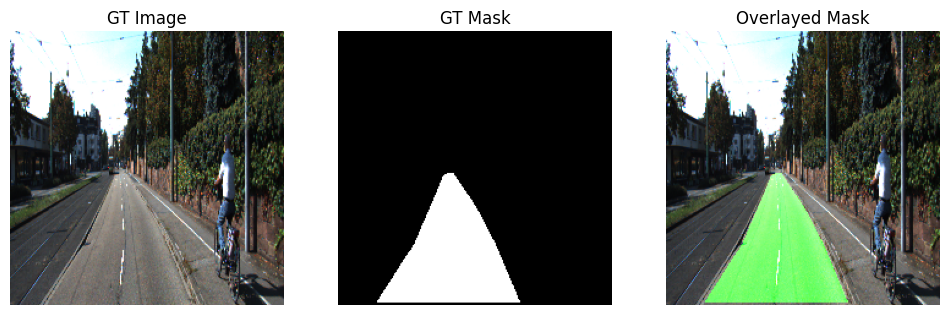

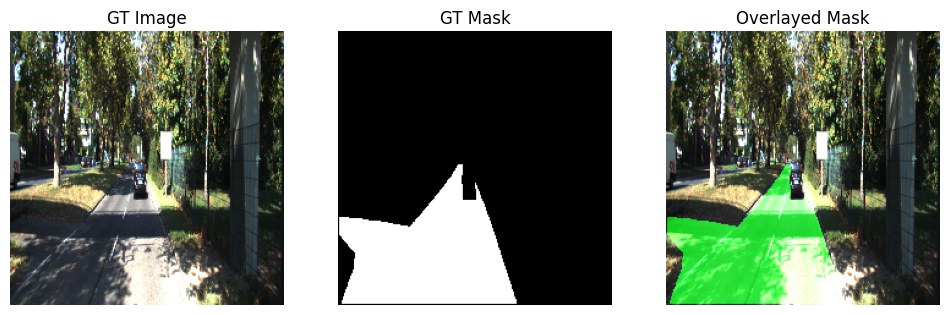

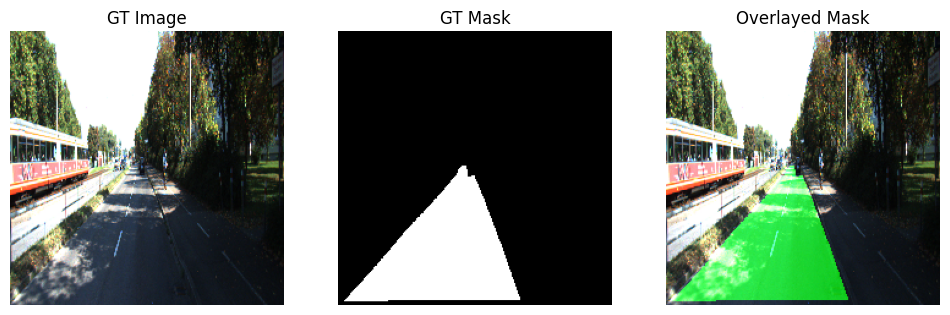

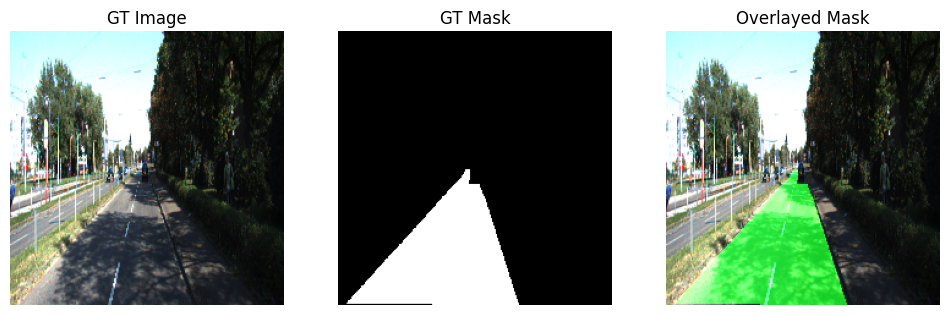

In [22]:
for batch_images, batch_masks in valid_loader:

    batch_images = denormalize(batch_images).permute(0, 2, 3, 1).numpy()
    batch_masks  = batch_masks.numpy()

    display_image_and_mask(images=batch_images, masks=batch_masks, color_mask=False, color_map=id2color_display)

    break

## Training and validation helper functions

In [24]:
# Training function
def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    num_classes,
    device = "cpu",
    epoch_idx = 800,
    total_epochs = 50
):

    model.train()

    loss_record = MeanMetric()
    acc_record = MulticlassAccuracy(num_classes = num_classes, average = 'micro')
    loader_len = len(loader)

    with tqdm(total = loader_len, ncols = 122, ascii = True) as tq:
        tq.set_description(f"Train::Epoch:{epoch_idx}/{total_epochs}")

        for data, target in loader:
            tq.update(1)

            data, target = data.to(device), target.to(device)

            # reset parameter gradients to zero
            optimizer.zero_grad()

            with amp.autocast(): #autocasting for mixed precision training
                logits = model(data)
                loss = F.cross_entropy(logits, target)

            # calculate gradients w.r.t training parameters on scaled loss
            scaler.scale(loss).backward()

            # update parameters using gradients
            scaler.step(optimizer)

            # updates the scale for next iteration
            sclaer.update()

            # Detach the output logits tnesor from the graph
            logits = logits.detach()

            # get the index across the channel axis of max logit score
            pred_idx = logits.argmax(dim = 1)

            # record and calculate batch accuracy using torchmetrics
            acc_record.update(pred_idx.cpu(), target.cpu())

            # record batch loss
            loss_record.update(loss.detach().cpu(), weight = data.shape[0])

            # update progress bar descriptions
            tq.set_postfix_str(s = f"Loss: {loss_record.compute():.4f}, Accuracy: {acc_record.compute():.4f}")

    # Get final loss and accuracy.
    epoch_loss = loss_record.compute()
    epoch_acc = acc_record.compute()

    return epoch_loss.item(), epoch_acc.item()



In [25]:
# validation function
def validate(
    model,
    loader,
    device,
    num_classes,
    epoch_idx,
    total_epochs,
):

    # Set model in evaluation mode.
    model.eval()

    loss_record = MeanMetric()
    acc_record = MulticlassAccuracy(num_classes=num_classes, average="micro")

    loader_len = len(loader)

    with tqdm(total=loader_len, ncols=122, ascii=True) as tq:
        tq.set_description(f"Valid :: Epoch: {epoch_idx}/{total_epochs}")

        for data, target in loader:
            tq.update(1)

            # Send data and target to GPU device if available.
            data     = data.to(device)
            target = target.to(device)

            with torch.no_grad():
                # Perform forward pass through the model.
                logits = model(data)

            # Calculate Cross-entropy loss.
            loss = F.cross_entropy(logits, target)

            # Record loss.
            loss_record.update(loss.cpu(), weight=data.shape[0])

            # Get the index of node with max score.
            pred = torch.argmax(logits, dim=1)

            # Calculate and record accuracy
            acc_record.update(pred.cpu(), target.cpu())

        valid_epoch_loss = loss_record.compute()
        valid_epoch_acc  = acc_record.compute()

        # Update progress bar description to display epoch log.
        tq.set_postfix_str(s=f"Loss: {valid_epoch_loss:.4f}, Acc: {valid_epoch_acc:.4f}")

    return valid_epoch_loss.item(), valid_epoch_acc.item()